## Prepare Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from data_util import *

In [2]:
import time

In [3]:
no_epochs=20
val_split=0.15
sequence_length = 16  # sequence length

#### Tranining Data set

In [4]:
train_df = read_data(get_files(r'.*Case[1-6]_CutFre200.xls'),cut_precent=0.1) # case 1 -6 for traning
train_df.head()

/Users/lahaale/Downloads/RL_network/BRNN_mobile_egde/data_Railway/data_util.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,df_tmp] )


,distance,acceleration,displacement,force
0,214.666667,3.933282,0.066135,149.348220
1,214.750000,3.615658,0.066152,151.348000
2,214.833333,2.675704,0.066173,157.732013
3,214.916667,1.334371,0.066197,166.934591
4,215.000000,0.114687,0.066221,175.241854


In [8]:
# Selecting the relevant features
train_features = train_df[['acceleration', 'displacement']]

X_train, y_train,idx_train = create_sequences(train_features, train_df['force'], train_df['distance'],sequence_length)

#### Testing Data set

In [9]:
test_df = read_data(get_files(r'V300.*Case[7-8]_CutFre200.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]

X_test300, y_test300,idx300 = create_sequences(test_features, test_df['force'],test_df['distance'],sequence_length)

/Users/lahaale/Downloads/RL_network/BRNN_mobile_egde/data_Railway/data_util.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,df_tmp] )


In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Conv1D, Dense,LSTM,Bidirectional,Input,GRU,Flatten,Dropout,Attention
from tensorflow.keras import regularizers
from tensorflow import keras

2024-10-14 15:39:27.453493: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [11]:
rnn_model = Sequential([
    SimpleRNN(32, input_shape=(sequence_length, 2), return_sequences=True),
    SimpleRNN(32, return_sequences=False),
    Dense(1)
])
rnn_model.compile(optimizer='adam', loss='mean_squared_error')
rnn_model.summary()

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 16, 32)         │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,233 (12.63 KB)

 Trainable params: 3,233 (12.63 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
rnn_history = rnn_model.fit(X_train, y_train, epochs=no_epochs, validation_split=val_split, verbose=1)


Epoch 1/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step - loss: 21937.7402 - val_loss: 1692.9941
Epoch 2/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 2134.6863 - val_loss: 337.5259
Epoch 3/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - loss: 425.8544 - val_loss: 341.4410
Epoch 4/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - loss: 358.1371 - val_loss: 304.6723
Epoch 5/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - loss: 344.9201 - val_loss: 337.7302
Epoch 6/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - loss: 334.5718 - val_loss: 308.9435
Epoch 7/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 31s 5ms/step - loss: 335.4055 - val_loss: 405.8921
Epoch 8/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 328.0477 - val_loss: 313.6532
Epoch 9/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - loss: 329.5871 - val_loss: 296.4085
Epoch 10/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - loss: 328.3853 - val_loss: 339.9413
Epoch 11/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 30s 5ms/step - loss: 3

In [13]:
rnn_model.save("models/rnn_model_fre_20_20.keras")
pd.DataFrame(data = rnn_history.history).to_csv("history/rnn_hist_fre2_20.csv")
# time.sleep(60*5)

In [14]:
gru_model = Sequential([
    GRU(32, input_shape=(sequence_length, 2), return_sequences=True),
    GRU(32, return_sequences=False),
    # SeqSelfAttention(attention_activation='sigmoid'),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mean_squared_error')
gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 16, 32)         │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,825 (38.38 KB)

 Trainable params: 9,825 (38.38 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
gru_history = gru_model.fit(X_train, y_train, epochs=no_epochs, validation_split=val_split, verbose=1)

Epoch 1/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 49s 8ms/step - loss: 21624.4062 - val_loss: 1688.8044
Epoch 2/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 55s 9ms/step - loss: 1852.8392 - val_loss: 368.3536
Epoch 3/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 53s 9ms/step - loss: 393.9233 - val_loss: 326.6489
Epoch 4/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 51s 8ms/step - loss: 335.4303 - val_loss: 417.0142
Epoch 5/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 52s 9ms/step - loss: 321.8723 - val_loss: 332.8166
Epoch 6/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 54s 9ms/step - loss: 314.6233 - val_loss: 364.1980
Epoch 7/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 52s 9ms/step - loss: 308.7426 - val_loss: 348.5623
Epoch 8/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 53s 9ms/step - loss: 307.7889 - val_loss: 315.6974
Epoch 9/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 61s 10ms/step - loss: 300.7298 - val_loss: 360.1352
Epoch 10/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 58s 10ms/step - loss: 300.2816 - val_loss: 311.5636
Epoch 11/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 55s 9ms/step - loss:

In [16]:
gru_model.save("models/gru_model_fre_20_20.keras")
pd.DataFrame(data = gru_history.history).to_csv("history/gru_hist_fre_20_20.csv")
time.sleep(60*5)

In [17]:
def cnn_gru_model(steps=sequence_length,feature_size=2, output_size=1,req=True):
    model = Sequential()
    model.add(Input(shape=(steps,feature_size)))
    model.add(Conv1D(64, 1, activation='relu'))
    model.add(GRU(32, return_sequences=True))
    model.add(GRU(32,return_sequences=False))
    model.add(Dense(output_size))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [18]:
cnn_gru_model = cnn_gru_model()
cnn_gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 16, 64)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 16, 32)         │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,969 (62.38 KB)

 Trainable params: 15,969 (62.38 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
cnn_gru_history = cnn_gru_model.fit(X_train, y_train,  epochs=no_epochs, validation_split=val_split, verbose=1)

Epoch 1/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 60s 9ms/step - loss: 22106.9648 - val_loss: 1705.1530
Epoch 2/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 55s 9ms/step - loss: 2693.7366 - val_loss: 444.3820
Epoch 3/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 57s 9ms/step - loss: 503.4300 - val_loss: 363.3178
Epoch 4/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 56s 9ms/step - loss: 345.4462 - val_loss: 390.8619
Epoch 5/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 56s 9ms/step - loss: 327.8964 - val_loss: 347.4341
Epoch 6/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 60s 10ms/step - loss: 318.6872 - val_loss: 298.7497
Epoch 7/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 61s 10ms/step - loss: 312.3001 - val_loss: 348.7576
Epoch 8/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 58s 10ms/step - loss: 304.2841 - val_loss: 334.5843
Epoch 9/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 57s 9ms/step - loss: 300.8345 - val_loss: 337.9879
Epoch 10/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 56s 9ms/step - loss: 292.9773 - val_loss: 306.6940
Epoch 11/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 57s 9ms/step - loss

In [20]:
cnn_gru_model.save("models/cnn_gru_model_fre_20_20.keras")
pd.DataFrame(data = cnn_gru_history.history).to_csv("history/cnn_gru_hist_fre_20_20.csv")
# time.sleep(60*5)

In [21]:
# reg = regularizers.l1_l2(0.01)
def lstm_model(steps=sequence_length,feature_size=2, output_size=1,req=True):
    model = Sequential()
    # model.add(Input(shape=(steps,feature_size)))
    # model.add(Conv1D(64, 1, activation='relu'))
    model.add(LSTM(32,input_shape=(sequence_length, 2), return_sequences=True))
    model.add(LSTM(32,return_sequences=False))
    model.add(Dense(output_size))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [22]:
lstm_model = lstm_model()
lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16, 32)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,833 (50.13 KB)

 Trainable params: 12,833 (50.13 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
lstm_history = lstm_model.fit(X_train, y_train,  epochs=no_epochs, validation_split=val_split, verbose=1)

Epoch 1/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - loss: 21779.5684 - val_loss: 1691.2706
Epoch 2/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - loss: 1964.2201 - val_loss: 384.7587
Epoch 3/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 39s 6ms/step - loss: 420.6692 - val_loss: 359.8817
Epoch 4/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - loss: 344.6970 - val_loss: 297.7179
Epoch 5/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - loss: 331.2696 - val_loss: 329.5728
Epoch 6/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - loss: 321.5753 - val_loss: 333.2805
Epoch 7/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 45s 7ms/step - loss: 316.1659 - val_loss: 335.2841
Epoch 8/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 45s 7ms/step - loss: 310.4991 - val_loss: 367.2680
Epoch 9/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 46s 8ms/step - loss: 307.6239 - val_loss: 326.2592
Epoch 10/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 46s 8ms/step - loss: 303.9510 - val_loss: 377.6647
Epoch 11/20
6067/6067 ━━━━━━━━━━━━━━━━━━━━ 46s 8ms/step - loss: 3

In [24]:
lstm_model.save("models/lstm_model_fre_20_20.keras")
pd.DataFrame(data = lstm_history.history).to_csv("history/lstm_hist_re_20_20.csv")
time.sleep(60*5)

In [25]:
rnn_pred = rnn_model.predict(X_test300)
gru_pred = gru_model.predict(X_test300)
lstm_pred = lstm_model.predict(X_test300)
cnn_gru_pred = cnn_gru_model.predict(X_test300)
# dnn_pred1 = dnn_model1.predict(test_features[sequence_length:])

826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [26]:
lstm_pred.shape

(26432, 1)

In [27]:
gru_pred.shape

(26432, 1)

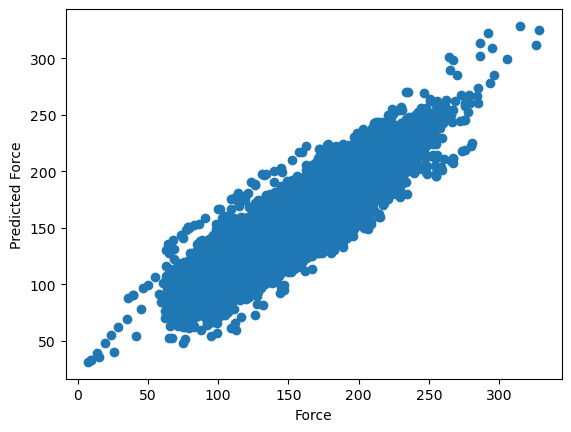

In [29]:
plt.scatter(y_test300,lstm_pred);
plt.xlabel("Force")
plt.ylabel("Predicted Force");

In [30]:
def plot_slot(start=500,end=601,filename="image"):
    epoch_count = idx300[start:end]

    plt.plot(epoch_count, y_test300[start:end], 'ro-',linewidth=2.0,markevery=20)
    # plt.plot(epoch_count, dnn_pred1[start:end], 'm--',linewidth=2.0)
    # plt.plot(epoch_count, dnn_pred[start:end], 'b--',linewidth=2.0)
    plt.plot(epoch_count, gru_pred[start:end], 'm^--',linewidth=2.0,markevery=20)
    plt.plot(epoch_count, cnn_gru_pred[start:end], 'bX--',linewidth=2.0,markevery=20)
    plt.plot(epoch_count, rnn_pred[start:end], 'yh--',linewidth=2.0,markevery=20)
    plt.plot(epoch_count, lstm_pred[start:end], 'gd--',linewidth=2.0,markevery=20)
    plt.legend(['Force',"GRU","CNN-GRU", "RNN","LSTM"])
    plt.xlabel('Distance (m)')
    plt.ylabel('Force (N)')
    #plt.title(title)
    plt.grid(True)
    plt.savefig("images/"+filename+".pdf",dpi=200,format = "pdf")
    # plt.show()
    

In [31]:
SMALL_SIZE = 14
MEDIUM_SIZE = 14
BIGGER_SIZE = 14

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rcParams["figure.figsize"] = (8,6)
plt.style.use("classic")


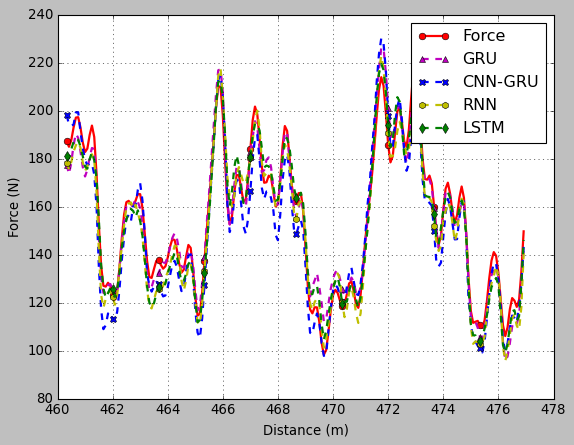

In [35]:
plot_slot(3400,3600,"ex2_train_Fre200_test_on_Fre200_Case7_8")

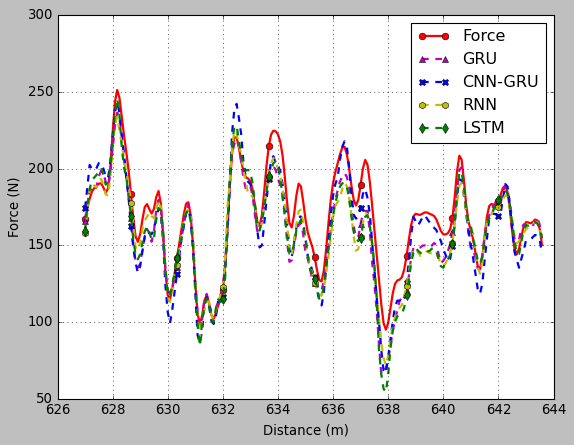

In [37]:
plot_slot(5400,5600,"ex1_train_Fre200_test_on_Fre200_Case7_8")

In [38]:
df_val = pd.DataFrame(data = {
              # "DNN-TM":dnn_history.history["val_loss"],
              "RNN":rnn_history.history["val_loss"],
              "GRU":gru_history.history["loss"],
              "CNN_GRU":cnn_gru_history.history["loss"],
              "LSTM":rnn_history.history["val_loss"]
                                         })
df_val.head()
df_val.to_csv("history/val_loss.csv")

In [39]:
df_val = pd.DataFrame(data = {
              # "DNN-TM":dnn_history.history["loss"],
              "RNN":rnn_history.history["loss"],
              "GRU":gru_history.history["loss"],
              "CNN_GRU":cnn_gru_history.history["loss"],
              "LSTM":rnn_history.history["loss"]
                                         })
df_val.head()
df_val.to_csv("history/loss.csv")

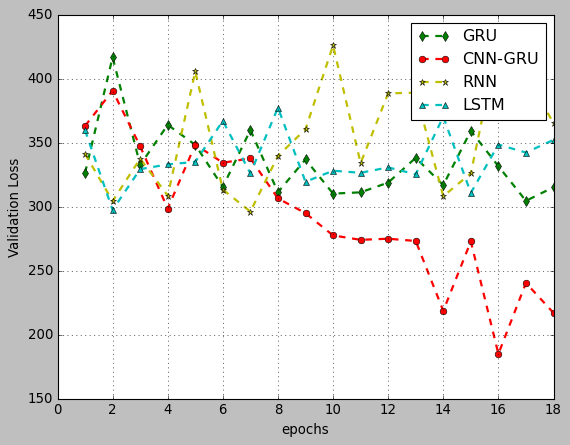

In [40]:
def plot_models_performance(gru=None, rnn=None, lstm=None,cnn_gru=None, title="Proctive Model"):
    lstm_accuracy = lstm.history['val_loss'][2:no_epochs]
    rnn_accuracy = rnn.history['val_loss'][2:no_epochs]
    gru_accuracy = gru.history['val_loss'][2:no_epochs]
    gru_att_acc = cnn_gru.history['val_loss'][2:no_epochs]


    # Create count of the number of epochs
    epoch_count = range(1, len(lstm_accuracy) + 1)

    # Visualize loss history
    plt.plot(epoch_count, gru_accuracy, 'gd--',linewidth=2.0)
    plt.plot(epoch_count, gru_att_acc, 'ro--',linewidth=2.0)
    plt.plot(epoch_count, rnn_accuracy, 'y*--',linewidth=2.0)
    plt.plot(epoch_count, lstm_accuracy, 'c^--',linewidth=2.0)
   
    plt.legend(['GRU','CNN-GRU', "RNN", "LSTM"])
    plt.xlabel('epochs')
    plt.ylabel('Validation Loss')
    plt.grid(True)
    plt.savefig("images/"+"val_loss.pdf",dpi=200,format = "pdf")

plot_models_performance(gru_history,rnn_history,lstm_history,cnn_gru_history,title="Adaptive Validation Loss")

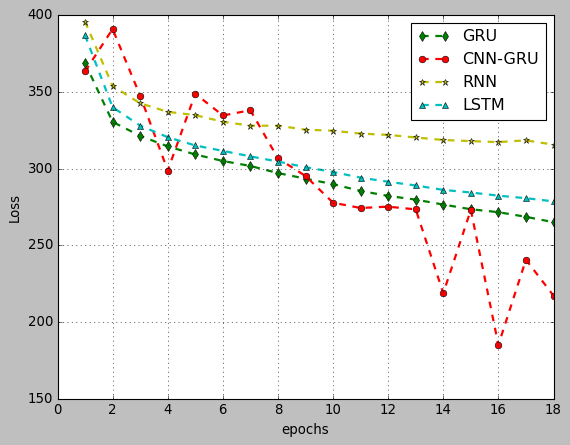

In [41]:
def plot_models_performance(gru=None, rnn=None, lstm=None, gru_att=None,title="Proctive Model"):
    lstm_accuracy = lstm.history['loss'][2:no_epochs]
    rnn_accuracy = rnn.history['loss'][2:no_epochs]
    gru_accuracy = gru.history['loss'][2:no_epochs]
    gru_att_acc = gru_att.history['val_loss'][2:no_epochs]


    # Create count of the number of epochs
    epoch_count = range(1, len(lstm_accuracy) + 1)

    # Visualize loss history
    plt.plot(epoch_count, gru_accuracy, 'gd--',linewidth=2.0)
    plt.plot(epoch_count, gru_att_acc, 'ro--',linewidth=2.0)
    plt.plot(epoch_count, rnn_accuracy, 'y*--',linewidth=2.0)
    plt.plot(epoch_count, lstm_accuracy, 'c^--',linewidth=2.0)
    # plt.plot(epoch_count, deep_nn_accuracy, 'b--')
    plt.legend(['GRU','CNN-GRU', "RNN", "LSTM"])
    plt.xlabel('epochs')
    plt.ylabel('Loss')
    # plt.title(title)
    plt.grid(True)
    plt.savefig("images/"+"loss.pdf",dpi=200,format = "pdf")

plot_models_performance(gru_history,rnn_history,lstm_history,cnn_gru_history,title="Loss")

In [42]:
test_df = read_data(get_files(r'V300.*Case[7-8]_CutFre200.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]

X_test, y_test,idx = create_sequences(test_features, test_df['force'],test_df['distance'],sequence_length)

/Users/lahaale/Downloads/RL_network/BRNN_mobile_egde/data_Railway/data_util.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,df_tmp] )


In [43]:
from sklearn.metrics import mean_squared_error
# from tensorflow.keras.metrics import MeanSquaredError 

In [44]:
def plot_error():
    rnn_pred = rnn_model.predict(X_test).reshape(-1)
    gru_pred = gru_model.predict(X_test).reshape(-1)
    lstm_pred = lstm_model.predict(X_test).reshape(-1)
    gru_att_pred = cnn_gru_model.predict(X_test).reshape(-1)
    # dnn_pred1 = dnn_model1.predict(test_features[sequence_length:])

    rnn_mse = mean_squared_error(y_test,rnn_pred)
    # dnn_tm_mse = mean_squared_error(dnn_pred, y_test)
    # dnn_mse = mean_squared_error(dnn_pred1, y_test)
    gru_mse = mean_squared_error(y_test,gru_pred)
    gru_att_mse = mean_squared_error(y_test,gru_att_pred)
    lstm_mse = mean_squared_error(y_test,lstm_pred)

    fig, ax = plt.subplots()
    fruits = ['RNN','GRU','CNN-GRU', 'LSTM']
    counts = [rnn_mse, gru_mse, gru_att_mse, lstm_mse]
    bar_labels = ['RNN','GRU','CNN-GRU', 'LSTM']
    bar_colors = ['tab:red', 'tab:blue', 'tab:red', 'tab:orange']

    ax.bar(fruits, counts, label=bar_labels, color=bar_colors)

    ax.set_ylabel('Mean Sqaure Error',fontsize=17) 
    # ax.set_title('Fruit supply by kind and color')
    # ax.legend(title='Models')
    plt.grid(True)

    plt.xticks(rotation=45,fontsize=17) 
    plt.yticks(fontsize=17) 
    # plt.show()
    # plt.savefig("images/"+finame+".pdf",dpi=200,format = "pdf")
    return counts

826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


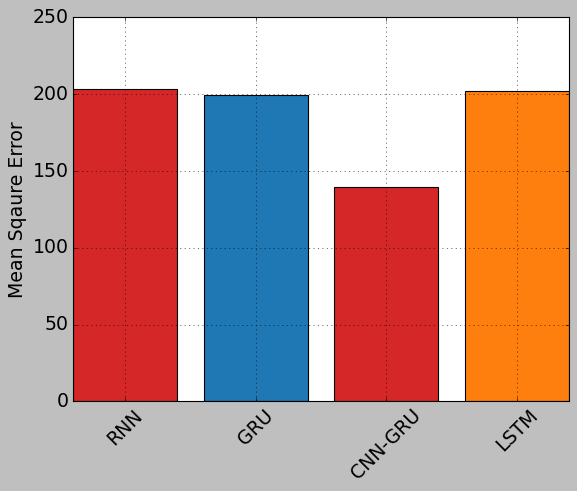

In [45]:
trained_Fre200_test_Fre200_V300 = plot_error()

In [46]:
test_df = read_data(get_files(r'V350.*Case[7-8]_CutFre200.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]

X_test, y_test,idx = create_sequences(test_features, test_df['force'],test_df['distance'],sequence_length)

/Users/lahaale/Downloads/RL_network/BRNN_mobile_egde/data_Railway/data_util.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,df_tmp] )


708/708 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


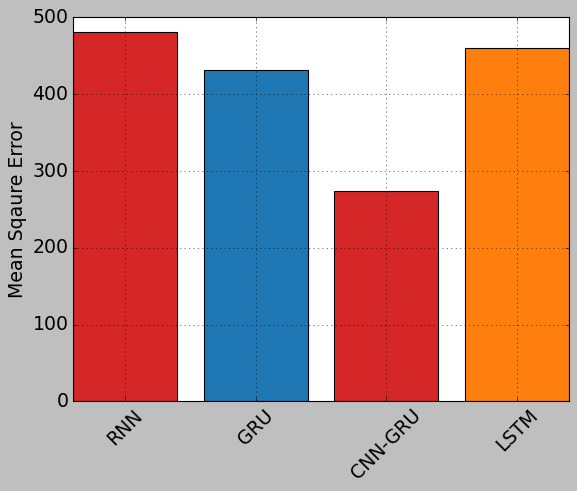

In [47]:
trained_Fre200_test_Fre200_V350 = plot_error()

/Users/lahaale/Downloads/RL_network/BRNN_mobile_egde/data_Railway/data_util.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,df_tmp] )


653/653 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


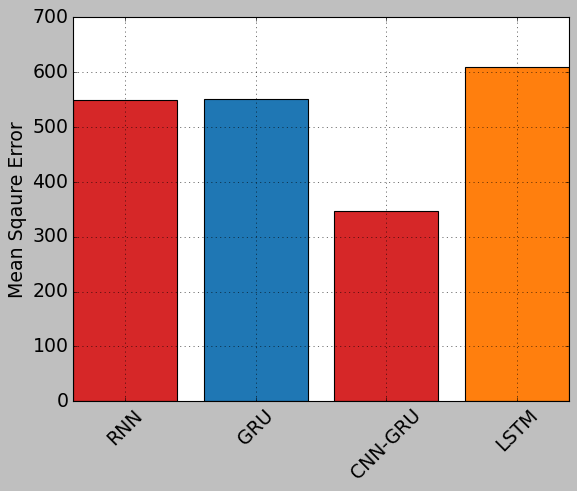

In [54]:
test_df = read_data(get_files(r'V380.*Case[7-8]_CutFre20.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]

X_test, y_test,idx = create_sequences(test_features, test_df['force'],test_df['distance'],sequence_length)
trained_Fre200_test_Fre200_V380 = plot_error()

In [61]:
error_df = pd.DataFrame(data={
    "300":trained_Fre200_test_Fre200_V300,
    "350":trained_Fre200_test_Fre200_V350,
    "380":trained_Fre200_test_Fre200_V380,
                             })
error_df.index = ['RNN','GRU','CNN-GRU', 'LSTM']
error_df.head()

,300,350,380
RNN,203.327726,481.007082,548.994217
GRU,199.249878,431.683004,550.480858
CNN-GRU,139.801713,273.298234,347.009098
LSTM,201.738471,460.276169,609.599612


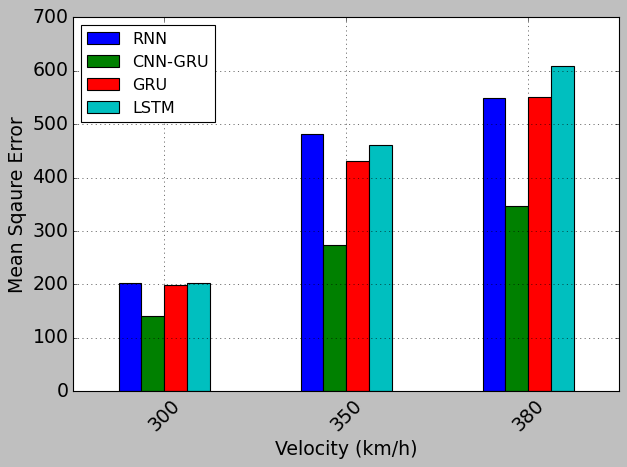

In [62]:
plt.rcParams.update({'figure.autolayout': True})
error_df.reindex(['RNN','CNN-GRU','GRU', 'LSTM']).transpose().plot(kind="bar")
plt.xlabel("Velocity (km/h)",fontsize=17) 
plt.ylabel("Mean Sqaure Error",fontsize=17) 
plt.xticks(rotation=45,fontsize=17) 
plt.yticks(fontsize=17) 
plt.grid(True)
plt.savefig("images/mode_freq200_200.pdf",dpi=200,format = "pdf")

/Users/lahaale/Downloads/RL_network/BRNN_mobile_egde/data_Railway/data_util.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,df_tmp] )


9325/9325 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step
9325/9325 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step
9325/9325 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step
9325/9325 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step


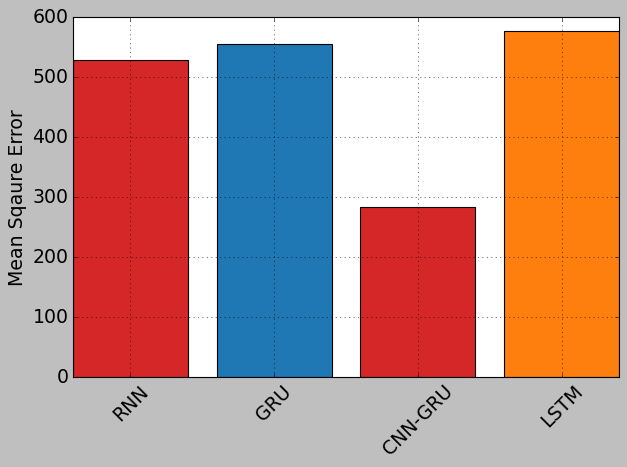

In [64]:
test_df = read_data(get_files(r'.*CutFre20.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]

X_test, y_test,idx = create_sequences(test_features, test_df['force'],test_df['distance'],sequence_length)
trained_Fre200_test_Fre20 = plot_error()

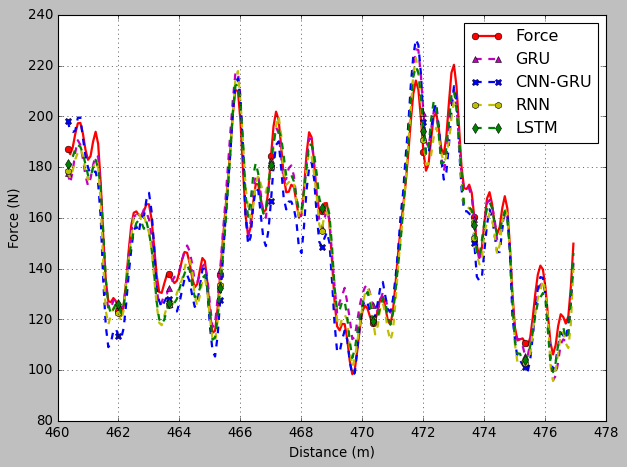

In [66]:
plot_slot(3400,3600,"ex2_train_Fre200_test_on_Fre20")

/Users/lahaale/Downloads/RL_network/BRNN_mobile_egde/data_Railway/data_util.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,df_tmp] )


9325/9325 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step
9325/9325 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step
9325/9325 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step
9325/9325 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step


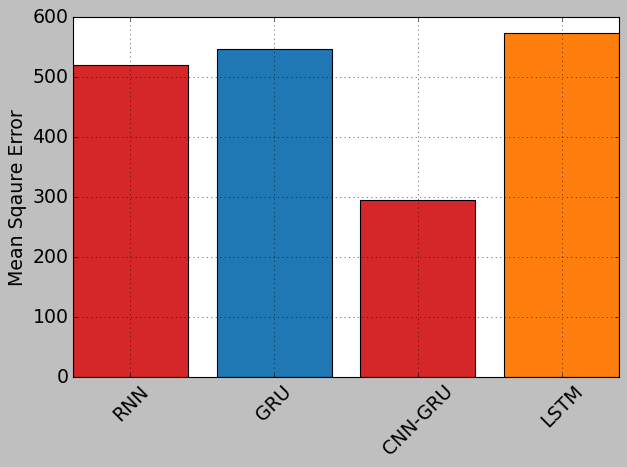

In [82]:
test_df = read_data(get_files(r'.*CutFre50.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]

X_test, y_test,idx = create_sequences(test_features, test_df['force'],test_df['distance'],sequence_length)
trained_Fre200_test_Fre50 = plot_error()

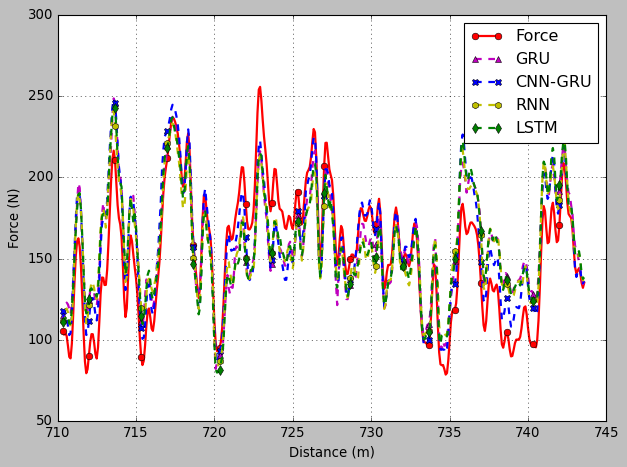

In [80]:
plot_slot(6400,6800,"ex1_train_Fre200_test_on_Fre50")

/Users/lahaale/Downloads/RL_network/BRNN_mobile_egde/data_Railway/data_util.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,df_tmp] )


9325/9325 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step
9325/9325 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step
9325/9325 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step
9325/9325 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step


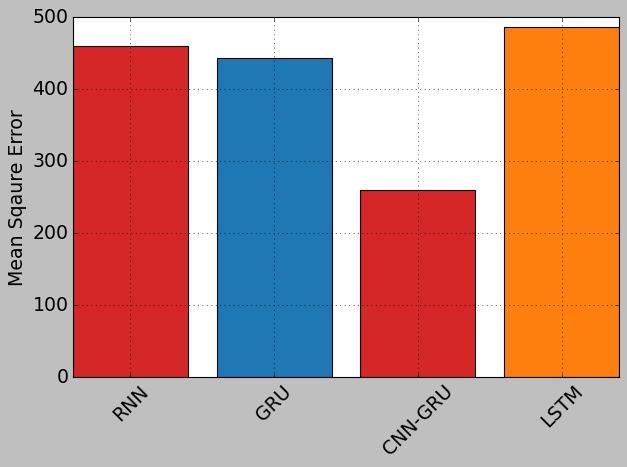

In [83]:
test_df = read_data(get_files(r'.*CutFre150.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]

X_test, y_test,idx = create_sequences(test_features, test_df['force'],test_df['distance'],sequence_length)
trained_Fre200_test_Fre150 = plot_error()

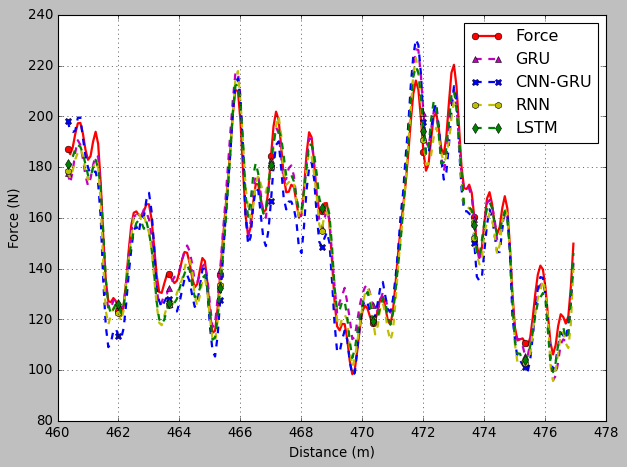

In [85]:
plot_slot(3400,3600,"ex3_train_Fre200_test_on_Fre150")

In [86]:
error_df = pd.DataFrame(data={
    "20":trained_Fre200_test_Fre20,
    "50":trained_Fre200_test_Fre50,
    "150":trained_Fre200_test_Fre150,
                             })
error_df.index = ['RNN','GRU','CNN-GRU', 'LSTM']
error_df.head()

,20,50,150
RNN,529.113676,520.033351,460.512297
GRU,556.005093,547.581215,443.048874
CNN-GRU,283.706454,295.910736,260.320557
LSTM,577.651577,573.140428,486.175831


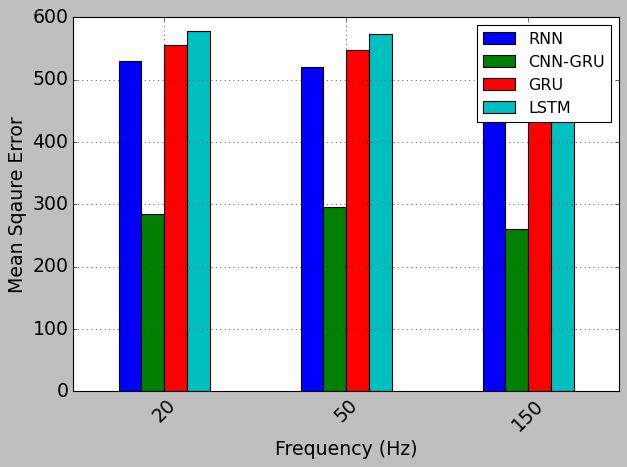

In [87]:
plt.rcParams.update({'figure.autolayout': True})
error_df.reindex(['RNN','CNN-GRU','GRU', 'LSTM']).transpose().plot(kind="bar")
plt.xlabel("Frequency (Hz)",fontsize=17) 
plt.ylabel("Mean Sqaure Error",fontsize=17) 
plt.xticks(rotation=45,fontsize=17) 
plt.yticks(fontsize=17) 
plt.grid(True)
plt.savefig("images/mode_freq200_to_f20_f50__f150.pdf",dpi=200,format = "pdf")